# Intro 

In this tutorial, we show the exploratory analysis on the perturbation indicators and covariates. This tutorial generates Fig. 4a,b in the manuscript.

# Set up

In [1]:
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman", repos = "https://cloud.r-project.org")

pacman::p_load(here, data.table, future.apply, ggplot2)


DIR <- here::here()   # resolves to the repo root automatically

meta_data_allchr <- fread(paste0(DIR,'/data/auxiliary/meta_data_allchr.csv'))
meta_data_allchr=as.data.frame(meta_data_allchr)
rownames(meta_data_allchr)=meta_data_allchr$cell_barcode
meta_data_allchr$gem_group=as.factor(meta_data_allchr$gem_group)
ncores=5

# Checking association between perturbation indicator and GEM group

In [2]:


# optional: enforce single-thread per worker
if (requireNamespace("RhpcBLASctl", quietly = TRUE)) {
  RhpcBLASctl::blas_set_num_threads(1)
  RhpcBLASctl::omp_set_num_threads(1)
}

plan(multisession, workers = ncores)

genes <- setdiff(unique(meta_data_allchr$gene), "non-targeting")

res <- future_lapply(genes, function(g) {
  
  # enforce single-thread inside worker
  if (requireNamespace("RhpcBLASctl", quietly = TRUE)) {
    RhpcBLASctl::blas_set_num_threads(1)
    RhpcBLASctl::omp_set_num_threads(1)
  }
  
  dtg <- data.table(
    gene  = meta_data_allchr$gene,
    batch = meta_data_allchr$gem_group
  )[gene %in% c("non-targeting", g)]
  
  dtg[, Dj := as.integer(gene == g)]
  
  out <- tryCatch({
    fit_batch <- glm(Dj ~ batch, data = dtg, family = binomial())
    
    data.table(
      gene = g,
      n_perturbed = sum(dtg$Dj == 1),
      n_control   = sum(dtg$Dj == 0),
      pval_batch = anova(fit_batch, test = "Chisq")[2, "Pr(>Chi)"]
    )
  }, error = function(e) {
    data.table(
      gene = g,
      n_perturbed = sum(dtg$Dj == 1),
      n_control   = sum(dtg$Dj == 0),
      
      pval_batch = NA_real_
    )
  })
  
  out
}, future.seed = TRUE)

res <- rbindlist(res)

# multiple testing correction

res[, p_adj_batch := p.adjust(pval_batch, method = "BH")]
saveRDS(res,paste0(DIR,'/results/application/chr_specific/res_gem.rds'))

In [3]:
res=readRDS(paste0(DIR,'/results/application/chr_specific/res_gem.rds'))

In [4]:
set.seed(1)

p_values <- res$pval_batch
p_values <- p_values[!is.na(p_values)]

plot_data <- data.frame(
  observed = -log10(sort(p_values)),
  expected = -log10(ppoints(length(p_values)))
)

# Fig. 4a

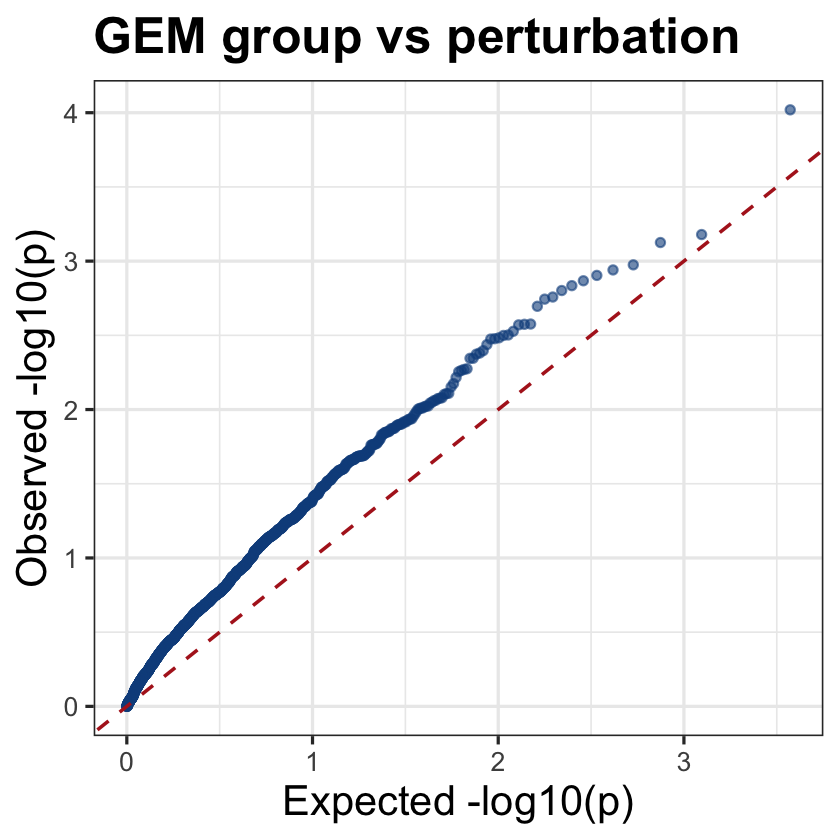

In [5]:


ggplot(plot_data, aes(x = expected, y = observed)) +
  geom_point(alpha = 0.6, color = "dodgerblue4", size = 2) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "firebrick", linewidth = 1) +
  labs(
    title = "GEM group vs perturbation",
    x = "Expected -log10(p)",
    y = "Observed -log10(p)"
  ) +
  theme_bw(base_size = 20) +
  theme(
    plot.title = element_text(face = "bold", size = 30),
    axis.title = element_text(size=25)
  )

# Checking association between perturbation indicator and mitochondrial percentage variable

In [6]:


genes <- setdiff(unique(meta_data_allchr$gene), "non-targeting")

dt0 <- data.table(
  mito = meta_data_allchr$mitopercent,
  gene = meta_data_allchr$gene
)[!is.na(mito) & !is.na(gene)]

res_mito <- lapply(genes, function(g) {
  dtg <- dt0[gene %in% c("non-targeting", g)][, .(
    Dj = as.integer(gene == g),
    mito = mito
  )]
  
  out <- tryCatch({
    fit <- glm(Dj ~ mito, data = dtg, family = binomial())
    sm <- coef(summary(fit))
    
    data.table(
      gene = g,
      effect = sm["mito", "Estimate"],
      pval = sm["mito", "Pr(>|z|)"],
      n_perturbed = sum(dtg$Dj),
      n_control = sum(dtg$Dj == 0)
    )
  }, error = function(e) {
    data.table(
      gene = g,
      effect = NA_real_,
      pval = NA_real_,
      n_perturbed = sum(dtg$Dj),
      n_control = sum(dtg$Dj == 0)
    )
  })
  
  out
})

res_mito <- rbindlist(res_mito)
res_mito[, p_adj := p.adjust(pval, method = "BH")]
saveRDS(res_mito,paste0(DIR,'/results/application/chr_specific/res_mito.rds'))

In [7]:
res_mito=readRDS(paste0(DIR,'/results/application/chr_specific/res_mito.rds'))

In [8]:
set.seed(1)
# Assuming res$pval_batch is your vector of p-values
p_values <- res_mito$pval
p_values <- p_values[!is.na(p_values)] # Ensure no NAs

# Create the dataframe for ggplot
plot_data <- data.frame(
  observed = -log10(sort(p_values)),
  expected = -log10(ppoints(length(p_values)))
)

# Fig. 4b

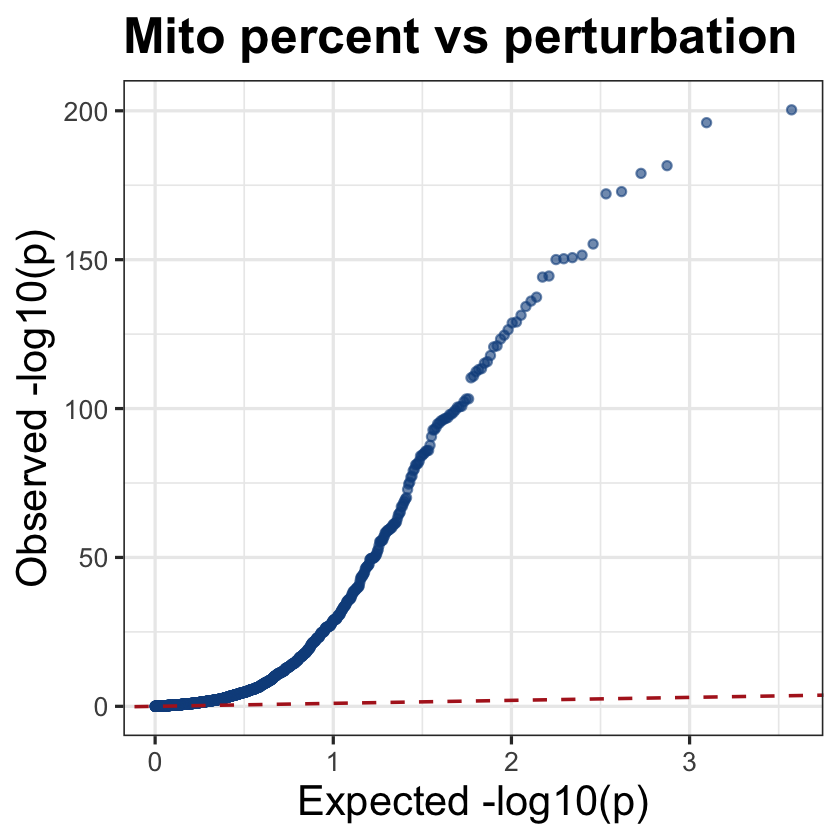

In [9]:
library(ggplot2)

ggplot(plot_data, aes(x = expected, y = observed)) +
  geom_point(alpha = 0.6, color = "dodgerblue4", size = 2) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "firebrick", linewidth = 1) +
  labs(
    title = "Mito percent vs perturbation",
    x = "Expected -log10(p)",
    y = "Observed -log10(p)"
  ) +
  theme_bw(base_size = 20) +
  theme(
    plot.title = element_text(face = "bold", size = 30),
    axis.title = element_text(size=25)
  )